# Analisis descriptivo inicial de las transcripciones. 


In [ ]:
import docx
import pandas as pd
import plotly.express as px
from wordcloud import WordCloud
import openpyxl

print("Todo instalado correctamente ✓")


Todo instalado correctamente ✓


### Lectura de archivos docx y conversion de ellos a un DataFrame.

In [ ]:
for carpeta in ["Focus_groups", "Interviews"]:
    ruta_carpeta = os.path.join(ruta_base, carpeta)
    archivos = os.listdir(ruta_carpeta)
    print(f"\n--- {carpeta} ({len(archivos)} archivos totales) ---")
    for archivo in archivos:
        print(archivo)



--- Focus_groups (12 archivos totales) ---
I112615a_OTR.docx
I112615b_OTR.docx
I112715a_OTR.docx
I112715b_OTR.docx
MC113015a_OTR.docx
MC113015b_OTR.docx
MC120115a_OTR.docx
MC120115b_OTR.docx
X112315a_OTR.docx
X112315b_OTR.docx
X112415a_OTR.docx
X112415b_OTR.docx

--- Interviews (62 archivos totales) ---
T- MC051115(a)_OTR.docx
T- X051615_GOB.docx
T-DF012015_GOV.docx
T-DF012815_ACA.docx
T-DF013015_ACA.docx
T-DF020415_ACA.docx
T-DF021215_ACA.docx
T-DF021815_ACA.docx
T-DF022515_ACA.docx
T-DF022615_ACA.docx
T-DF031215_ACA.docx
T-DF042115_GOV.docx
T-DF042215_GOV.docx
T-DF042415_GOB.docx
T-DF042915_GOB.docx
T-DF043015_OTR.docx
T-DF04615_GOV.docx
T-DF050615_GOV.docx
T-DF051215a_GOV.docx
T-DF051215b_GOB.docx
T-DF051315_GOV.docx
T-DF051415a_ACA.docx
T-DF051415b_ACA.docx
T-DF051915_GOV.docx
T-DF060515_gov.docx
T-DF062515_GOV.docx
T-DF062515_GOV_FV.docx
T-DF062615_GOV.docx
T-DF071515_GOV.docx
T-DF090215_OTR.docx
T-DF091815_GOV.docx
T-DF111814_GOV.docx
T-FED060415_gov.docx
T-FED090315_OTR.docx
T-

In [ ]:
import subprocess

def convertir_doc_a_docx(ruta_archivo):
    """Convierte .doc a .docx usando LibreOffice"""
    carpeta = os.path.dirname(ruta_archivo)
    subprocess.run([
        r"C:\Program Files\LibreOffice\program\soffice.exe",
        "--headless",
        "--convert-to", "docx",
        "--outdir", carpeta,
        ruta_archivo
    ], capture_output=True)
    # Retorna la ruta del archivo convertido
    return ruta_archivo.replace(".doc", ".docx")

datos = []

for carpeta in ["Focus_groups", "Interviews"]:
    ruta_carpeta = os.path.join(ruta_base, carpeta)
    for archivo in os.listdir(ruta_carpeta):
        ruta_archivo = os.path.join(ruta_carpeta, archivo)
        
        if archivo.endswith(".doc") and not archivo.endswith(".docx"):
            print(f"Convirtiendo: {archivo}")
            ruta_archivo = convertir_doc_a_docx(ruta_archivo)
            archivo = archivo.replace(".doc", ".docx")
        
        if archivo.endswith(".docx"):
            texto = extraer_texto(ruta_archivo)
            datos.append({
                "archivo": archivo,
                "tipo": carpeta,
                "texto": texto,
                "num_palabras": len(texto.split()),
                "num_caracteres": len(texto)
            })

df = pd.DataFrame(datos)
print(f"\nTotal de archivos cargados: {len(df)}")
df[["archivo", "tipo", "num_palabras", "num_caracteres"]]



Total de archivos cargados: 74


,archivo,tipo,num_palabras,num_caracteres
0,I112615a_OTR.docx,Focus_groups,12088,66109
1,I112615b_OTR.docx,Focus_groups,12930,72398
2,I112715a_OTR.docx,Focus_groups,15389,85222
3,I112715b_OTR.docx,Focus_groups,19448,107232
4,MC113015a_OTR.docx,Focus_groups,14162,78280
...,...,...,...,...
69,T-X050715(a)_GOB.docx,Interviews,3977,22693
70,T-X051115_GOB_AF.docx,Interviews,8045,45990
71,T-X051215_ACA.docx,Interviews,4050,25349
72,T-X052515_otr.docx,Interviews,12313,70656


In [ ]:
import os

ruta_libreoffice = r"C:\Program Files\LibreOffice\program\soffice.exe"
print(os.path.exists(ruta_libreoffice))


True


En la carpeta original hay algunos archivos con extension .doc que la libreria python-docx no carga bien. En esta seccion identificamos esos archivos y creamos copias suyas con extension .docx en la misma carpeta.

In [ ]:
for carpeta in ["Focus_groups", "Interviews"]:
    ruta_carpeta = os.path.join(ruta_base, carpeta)
    doc_count = 0
    docx_count = 0
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".docx"):
            docx_count += 1
        elif archivo.endswith(".doc"):
            doc_count += 1
    print(f"{carpeta}: {docx_count} archivos .docx, {doc_count} archivos .doc")


Focus_groups: 12 archivos .docx, 0 archivos .doc
Interviews: 62 archivos .docx, 0 archivos .doc


In [ ]:
datos = []

for carpeta in ["Focus_groups", "Interviews"]:
    ruta_carpeta = os.path.join(ruta_base, carpeta)
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".docx"):
            ruta_archivo = os.path.join(ruta_carpeta, archivo)
            texto = extraer_texto(ruta_archivo)
            datos.append({
                "archivo": archivo,
                "tipo": carpeta,
                "texto": texto,
                "num_palabras": len(texto.split()),
                "num_caracteres": len(texto)
            })

df = pd.DataFrame(datos)
print(f"Total de archivos cargados: {len(df)}")
df[["archivo", "tipo", "num_palabras", "num_caracteres"]]


Total de archivos cargados: 74


,archivo,tipo,num_palabras,num_caracteres
0,I112615a_OTR.docx,Focus_groups,12088,66109
1,I112615b_OTR.docx,Focus_groups,12930,72398
2,I112715a_OTR.docx,Focus_groups,15389,85222
3,I112715b_OTR.docx,Focus_groups,19448,107232
4,MC113015a_OTR.docx,Focus_groups,14162,78280
...,...,...,...,...
69,T-X050715(a)_GOB.docx,Interviews,3977,22693
70,T-X051115_GOB_AF.docx,Interviews,8045,45990
71,T-X051215_ACA.docx,Interviews,4050,25349
72,T-X052515_otr.docx,Interviews,12313,70656


### Creacion de tabla resumen con estadisticas basicas por tipo de documento. 

In [ ]:
resumen = df.groupby("tipo").agg(
    num_archivos=("archivo", "count"),
    palabras_total=("num_palabras", "sum"),
    palabras_promedio=("num_palabras", "mean"),
    palabras_minimo=("num_palabras", "min"),
    palabras_maximo=("num_palabras", "max")
).round(0).astype(int)

print("=== Resumen general ===")
resumen


=== Resumen general ===


,num_archivos,palabras_total,palabras_promedio,palabras_minimo,palabras_maximo
tipo,,,,,
Focus_groups,12,180708,15059,8338,19448
Interviews,62,440687,7108,326,16082


In [ ]:
# Aqui estamos revisando cuales son los archivos de las entrevistas que tienen 
# menos de 1000 palabras para revisarlos y saber si no es un error.
sospechosos = df[df["num_palabras"] < 1000].sort_values("num_palabras")
sospechosos[["archivo", "tipo", "num_palabras"]]


,archivo,tipo,num_palabras
20,T-DF022515_ACA.docx,Interviews,326


Se reviso el archivo de audio de este valor minimo y se observo que la entrevista es muy corta porque el audio en si es muy corto. Parece ser que la grabadora de esta entrevista se corto y no pudo recolectar toda esta.

### Visualizacion de la distribucion de los archivos en la longitud de palabras agrupados por tipo. 

In [ ]:
fig = px.box(
    df, 
    x="tipo", 
    y="num_palabras",
    color="tipo",
    points="all",
    hover_data=["archivo"],
    title="Distribución de longitud de transcripciones por tipo",
    labels={"tipo": "Tipo de documento", "num_palabras": "Número de palabras"}
)

fig.show()


## Nube de palabras

Vamos primero a definir las stopwords para los archivos.

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Stopwords en español
stopwords_es = set([
    "de", "la", "que", "el", "en", "y", "a", "los", "se", "del",
    "las", "un", "por", "con", "no", "una", "su", "para", "es",
    "al", "lo", "como", "más", "pero", "sus", "le", "ya", "o",
    "este", "sí", "porque", "esta", "entre", "cuando", "muy",
    "sin", "sobre", "también", "me", "hasta", "hay", "donde",
    "quien", "desde", "todo", "nos", "durante", "uno", "ni",
    "contra", "ese", "eso", "ante", "ellos", "e", "esto", "mi",
    "antes", "algunos", "qué", "unos", "yo", "otro", "otras",
    "otra", "él", "tanto", "esa", "estos", "mucho", "quienes",
    "nada", "muchos", "cual", "poco", "ella", "estar", "haber",
    "estas", "fue", "ha", "aquí", "pues", "tiene", "son", "así"
])

print(f"Stopwords cargadas: {len(stopwords_es)}")


Stopwords cargadas: 86


In [ ]:
stopwords_extra = {
    # Verbos vacíos
    "hace", "hacer", "viene", "tener", "tengo", "tienen", "dicen", 
    "dice", "llega", "vamos", "van", "sea", "era", "estamos", "están", 
    "hacen", "creo", "digo", "decir",
    # Pronombres y determinantes
    "todos", "toda", "mismo", "algo", "mucha", "cada", "esas", "esos", "alguna",
    # Etiquetas de transcripción
    "Moderadora", "Individuo", "E1", "E2", "Intervención", "e1", "e2",
    # Adverbios y conectores
    "ahora", "ahorita", "luego", "siempre", "nunca", "también", 
    "después", "veces", "lado", "allá", "abajo",
    # Palabras demasiado generales
    "cosa", "cómo", "parte", "tipo", "manera", "tema", "caso", "ejemplo",
    # Las que agregamos antes
    "entonces", "si", "pues", "así", "aquí", "acá", "ahí", "bueno", 
    "bien", "ver", "ser", "hay", "van", "tan", "puede", "solo"
}

stopwords_es = stopwords_es | stopwords_extra
print(f"Stopwords totales: {len(stopwords_es)}")


Stopwords totales: 150


In [ ]:
stopwords_extra2 = {
    "voy", "hecho", "han", "digamos", "vez", "muchas", "te", 
    "sino", "moderador", "ve", "cosas", "hacia", "da", "está", "sido", "decía"
    ,"les", "moderadora"
}

stopwords_es = stopwords_es | stopwords_extra2
print(f"Stopwords totales: {len(stopwords_es)}")


Stopwords totales: 168


In [ ]:
stopwords_extra3 = {
    "gracias", "dos", "usted", "pasa", "mejor", "señor", "señora", "menos"
}

stopwords_es = stopwords_es | stopwords_extra3
print(f"Stopwords totales: {len(stopwords_es)}")


Stopwords totales: 176


Ahora vamos a genrar las nubes de palabras.

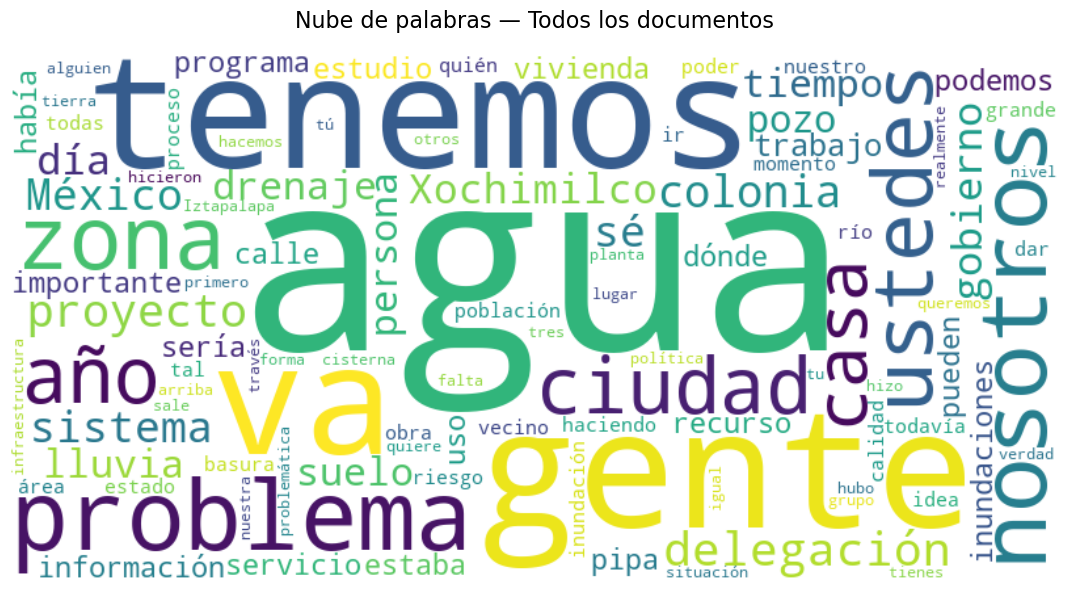

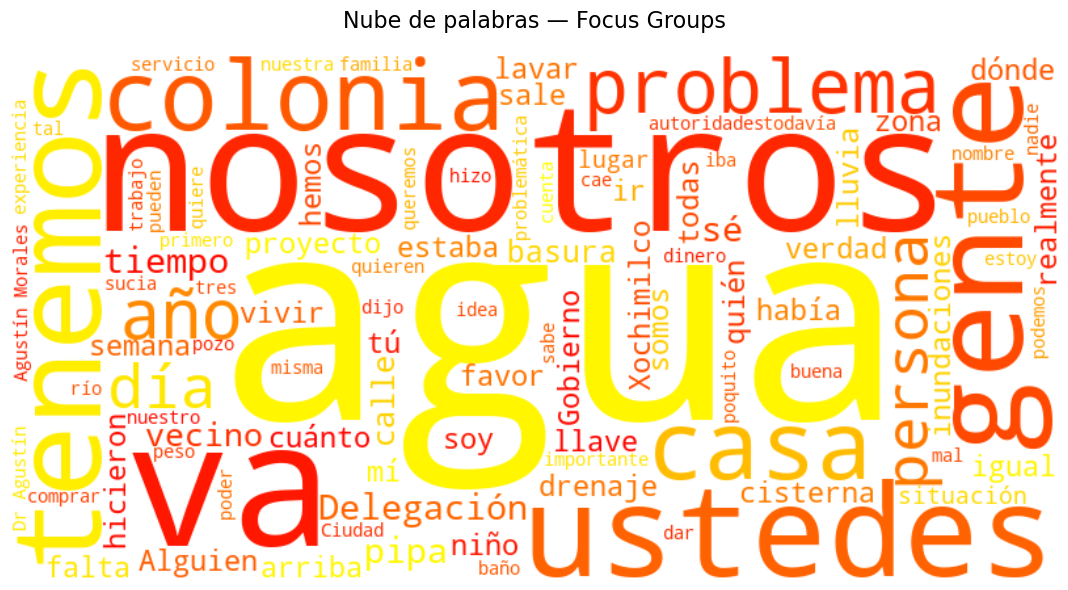

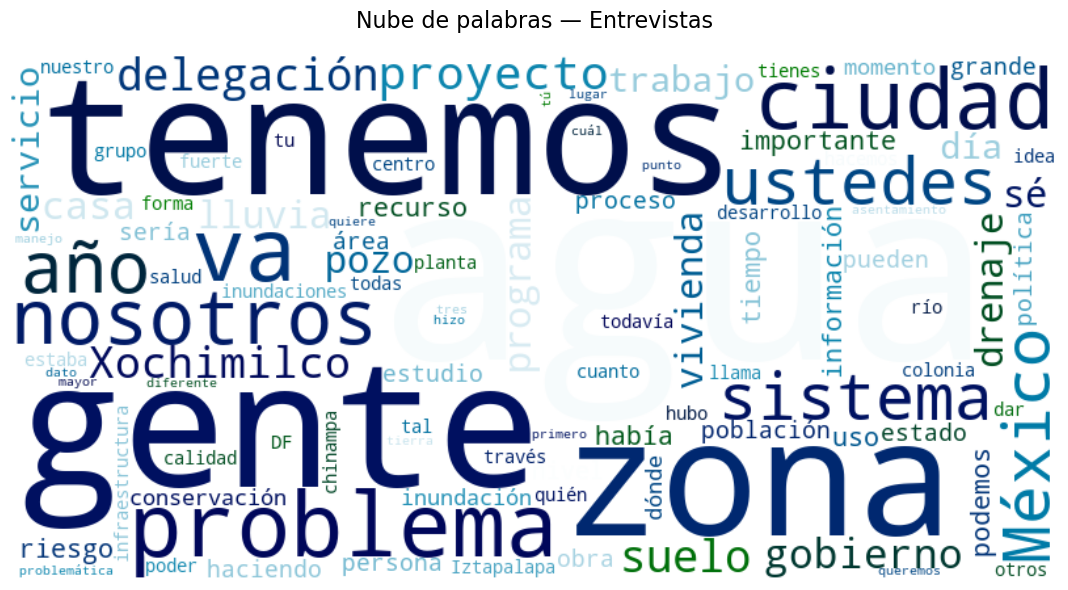

In [ ]:
import matplotlib.pyplot as plt

# Unir todo el texto
texto_total = " ".join(df["texto"].tolist())
texto_fg = " ".join(df[df["tipo"] == "Focus_groups"]["texto"].tolist())
texto_int = " ".join(df[df["tipo"] == "Interviews"]["texto"].tolist())

# Función para generar nube
def generar_nube(texto, titulo, color):
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        stopwords=stopwords_es,
        colormap=color,
        max_words=100
    ).generate(texto)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo, fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# Generar las tres nubes
generar_nube(texto_total, "Nube de palabras — Todos los documentos", "viridis")
generar_nube(texto_fg, "Nube de palabras — Focus Groups", "autumn")
generar_nube(texto_int, "Nube de palabras — Entrevistas", "ocean")


## Análisis de frecuencias (cuantificar lo observado en las nubes de palabras)

In [ ]:
from collections import Counter

def contar_palabras(texto, stopwords):
    palabras = [
        palabra.lower().strip(".,;:¿?¡!()\"'")
        for palabra in texto.split()
        if palabra.lower().strip(".,;:¿?¡!()\"'") not in stopwords
        and len(palabra) > 2
    ]
    return Counter(palabras)

# Contar por tipo
conteo_fg = contar_palabras(texto_fg, stopwords_es)
conteo_int = contar_palabras(texto_int, stopwords_es)

# Top 20 de cada uno
top_fg = pd.DataFrame(conteo_fg.most_common(20), columns=["palabra", "frecuencia"])
top_fg["tipo"] = "Focus_groups"

top_int = pd.DataFrame(conteo_int.most_common(20), columns=["palabra", "frecuencia"])
top_int["tipo"] = "Interviews"

# Unir
top_total = pd.concat([top_fg, top_int])

# Graficar
fig = px.bar(
    top_total,
    x="frecuencia",
    y="palabra",
    color="tipo",
    facet_col="tipo",
    orientation="h",
    title="Top 20 palabras más frecuentes por tipo de documento",
    labels={"frecuencia": "Frecuencia", "palabra": ""},
    height=800,
    width=1000
)

fig.update_layout(
    showlegend=False,
    yaxis=dict(tickmode="linear"),
    yaxis2=dict(tickmode="linear")
)

fig.show()
